# Task 4.10 — Geo Mean HAI Across Vaccine Strains (D365, Durability)

**4.10 Predict antibody durability - all 3 vaccine strains (D365)**
* Training Data: Demographics + Day 0 + Day 7 innate + **Day 28**
* Assay: HAI / Measure: Geo mean HAI / Metric: Spearman correlation
* Full description: Geo mean of HAI across the 3 vaccine strains at Day 365

> **Note — missing strains:** only `Vic B/Austria/1359417/2021` has D365 measurements in the training data. H1N1 A/Victoria/4897/2022 stops at D28; H3N2 A/Massachusetts/18/2022 is absent entirely. This task collapses to predicting Vic B D365 — effectively the same target as Task 4.9.

---

**Target:** arithmetic mean of log2 HAI at D365 across available vaccine strains = log2(geometric mean) on the raw titer scale. `np.exp2` is applied to predictions before saving.

**Features:** all columns available at D0 + D7 + D28 (durability task — D28 is allowed). Only D365 columns excluded.

**CV:** 5-fold; Spearman correlation on holdout predictions.

In [1]:
VACCINE_STRAINS = [
    'H1N1 A/Victoria/4897/2022',
    'H3N2 A/Massachusetts/18/2022',
    'Vic B/Austria/1359417/2021',
]
AUTO_ML_MAX_RUNTIME_SECONDS = 1200

In [2]:
PARQUET_PATH = '../merged_data/combined.parquet'
CHALLENGE_DATA_PATH = '../cleaned_data'
SUBMISSION_PATH = '../automl_submission'

In [3]:
import io
import os
import tempfile
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

warnings.filterwarnings('ignore', category=UserWarning, module='h2o')
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,51 mins 18 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 17 days
H2O_cluster_name:,H2O_from_python_User_302xe5
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,10.51 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [4]:
data = h2o.import_file(PARQUET_PATH)
print(f'Training data shape: {data.shape}')

challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Training data shape: (3757, 110063)
Challenge shape: (40, 23)


In [5]:
# Compute target in pandas and round-trip via parquet so H2O reads NaN as H2O NA
hai_d365_cols = [c for c in data.columns if c.startswith('HAI_') and c.endswith('_d365')]
vaccine_d365_cols = [c for c in hai_d365_cols if any(s in c for s in VACCINE_STRAINS)]

pd_hai_d365 = data[hai_d365_cols].as_data_frame()
target_series = pd_hai_d365[vaccine_d365_cols].mean(axis=1, skipna=True)

_fd, _tmp = tempfile.mkstemp(suffix='.parquet')
os.close(_fd)
target_series.to_frame(name='TARGET_4_10').to_parquet(_tmp, index=False)
data = data.cbind(h2o.import_file(_tmp))
os.unlink(_tmp)

print(f'Training samples with valid target: {target_series.notna().sum()}')

C:\Users\User\anaconda3\envs\cmi-flu-prediction-challenge-capstone\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Training samples with valid target: 492


---
## AutoML Training

In [6]:
# D28 features allowed for durability — exclude only D365 columns
y = 'TARGET_4_10'
x = [c for c in data.columns
     if not c.endswith('_d365')
     and c != 'participant_id' and c != y]

train = data[data[y].isna() == 0]
print(f'Training samples: {train.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(max_models=10, seed=1, nfolds=5,
                keep_cross_validation_predictions=True,
                max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=train)
print('Training complete.')

Training samples: 492  |  Features: 110003
Training complete.


In [7]:
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

model_id                           rmse      mse       mae     rmsle    mean_residual_deviance
GLM_1_AutoML_3_20260429_204544  1.01699  1.03427  0.761665  0.196521                   1.03427
GBM_1_AutoML_3_20260429_204544  1.11965  1.25362  0.807661  0.20433                    1.25362
[2 rows x 6 columns]



In [8]:
cv_preds = aml.leader.cross_validation_holdout_predictions().as_data_frame()['predict']
actuals = train[y].as_data_frame()[y]
rho, pval = spearmanr(actuals, cv_preds)
print(f'Task 4.10 — Spearman (5-fold CV): {rho:.3f}  (p={pval:.4f})')

C:\Users\User\anaconda3\envs\cmi-flu-prediction-challenge-capstone\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\User\anaconda3\envs\cmi-flu-prediction-challenge-capstone\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Task 4.10 — Spearman (5-fold CV): 0.785  (p=0.0000)


Leader model: GLM_1_AutoML_3_20260429_204544


,variable,relative_importance,scaled_importance,percentage
0,HAI_Vic B/Austria/1359417/2021_d28,0.771532,1.000000,0.095150
1,HAI_Vic B/Austria/1359417/2021_d0,0.469453,0.608468,0.057896
2,PART_age,0.259304,0.336090,0.031979
3,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d28,0.226421,0.293469,0.027924
4,HAI_Vic B/Colorado/6/2017_d28,0.189453,0.245554,0.023365
5,HAI_H3N2 A/Darwin/9/2021_d28,0.145742,0.188899,0.017974
6,HAI_Vic B/Colorado/6/2017_d0,0.133706,0.173299,0.016489
7,HAI_H1N1 A/Brisbane/2/2018_d28,0.132918,0.172278,0.016392
8,HAI_Vic B/Washington/2/2019_d0,0.107548,0.139396,0.013264
9,HAI_H3N2 A/Kansas/14/2017_d0,0.102512,0.132868,0.012642


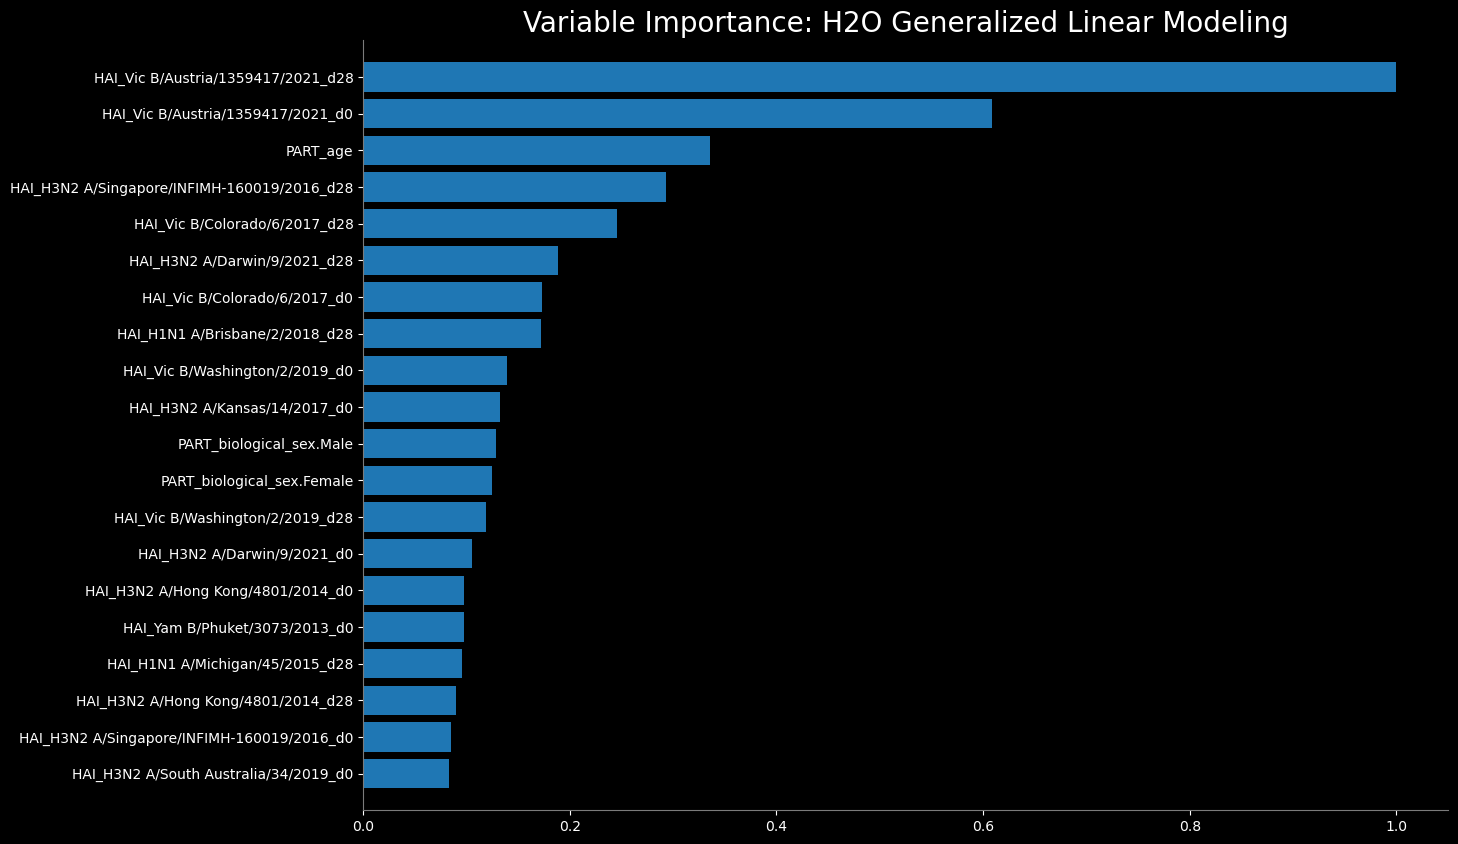

<Figure size 640x480 with 0 Axes>

In [9]:
print(f'Leader model: {aml.leader.model_id}')
varimp = aml.leader.varimp(use_pandas=True)
display(varimp.head(20))
aml.leader.varimp_plot(num_of_features=20)

In [10]:
challenge_hf = h2o.H2OFrame(challenge_data)
y_pred = aml.leader.predict(challenge_hf).as_data_frame()['predict']

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.10': np.exp2(y_pred),
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_10.csv', index=False)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\User\anaconda3\envs\cmi-flu-prediction-challenge-capstone\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,Participant_ID,Task_4.10
0,2024_UGA.ID_077,19.896148
1,2024_UGA.ID_086,35.702913
2,2024_UGA.ID_128,14.220334
3,2024_UGA.ID_170,15.662495
4,2024_UGA.ID_179,33.145592
5,2024_UGA.ID_215,17.481673
6,2024_UGA.ID_219,33.359288
7,2024_UGA.ID_275,26.698143
8,2024_UGA.ID_295,76.879677
9,2024_UGA.ID_296,23.615896


In [11]:
h2o.cluster().shutdown()

H2O session _sid_a6c9 was not closed properly.


---
## Conclusion

- **Leader model:** (fill after run)
- **CV Spearman:** (fill after run)

**Target:** log2(geomean) of vaccine strain HAI titers at D365. In practice collapses to Vic B/Austria/1359417/2021 D365 only, since the other vaccine strains have no D365 measurements in training data — making this effectively identical to Task 4.9.

D28 features are included as predictors (durability task allowance), which gives this model more signal than the D28 tasks.

Submission saved to `automl_submission/task_4_10.csv` (raw titer scale via `np.exp2`).